Mounted at /content/drive
Loading trained model from: /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/potato_cnn_best.keras
✅ Trained Model loaded successfully!
✅ Unseen Test Data Loaded! X_test shape: (216, 224, 224, 3), y_test shape: (216,)
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step

🎯 FINAL TEST ACCURACY (Unseen Test Data): 98.15%

=================== CLASSIFICATION REPORT ===================

              precision    recall  f1-score   support

     Healthy     0.8889    1.0000    0.9412        16
Early_Blight     1.0000    0.9800    0.9899       100
 Late_Blight     0.9800    0.9800    0.9800       100

    accuracy                         0.9815       216
   macro avg     0.9563    0.9867    0.9704       216
weighted avg     0.9825    0.9815    0.9817       216



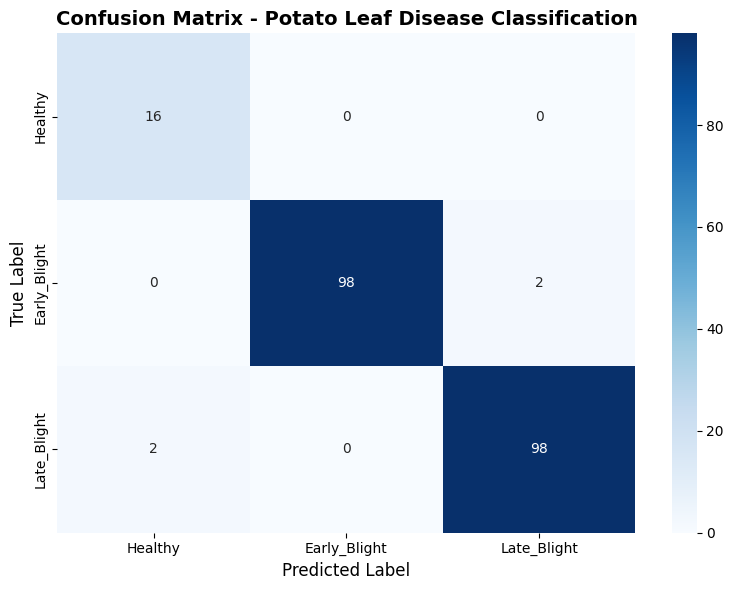

In [1]:
# ==============================================================================
# STEP 5: MODEL EVALUATION ON UNSEEN TEST DATA
# File: 5th_Model_Evaluation/cnn_evaluation.ipynb
# Model Loaded From: 6th_Trained_Model/potato_cnn_best.keras
# ==============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Mount Google Drive & Define Paths
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Plant Disease Detection (Computer Vision)'
except ImportError:
    PROJECT_DIR = os.path.abspath('..')

# 💡 Fixed Folder Name to '6th Trained_Model'
MODEL_PATH = os.path.join(PROJECT_DIR, '6th Trained_Model', 'potato_cnn_best.keras')
PREPROC_FILE_PATH = os.path.join(PROJECT_DIR, '3rd Preprocessing', 'processed_potato_data.npz')

# 2. Load Saved Best Model
print("Loading trained model from:", MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Trained Model loaded successfully!")

# 3. Load UNSEEN TEST Data Only (X_test, y_test)
data = np.load(PREPROC_FILE_PATH)
X_test = data['X_test']
y_test = data['y_test']
print(f"✅ Unseen Test Data Loaded! X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# 4. Generate Predictions & Calculate Accuracy
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 FINAL TEST ACCURACY (Unseen Test Data): {test_acc * 100:.2f}%")

# 5. Print Classification Report (Precision, Recall, F1-Score)
class_names = ['Healthy', 'Early_Blight', 'Late_Blight']
print("\n=================== CLASSIFICATION REPORT ===================\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# 6. Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Potato Leaf Disease Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


In [2]:
# ==============================================================================
# MODEL VERIFICATION & INTEGRITY CHECK
# File: 6th_Trained_Model / Inspection Script
# ==============================================================================

import os
import tensorflow as tf

# 1. Mount Google Drive & Define Base Path
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Plant Disease Detection (Computer Vision)'
except ImportError:
    PROJECT_DIR = os.path.abspath('..')

# 2. Dynamic Folder Path Handler ('6th Trained_Model' or '06_Trained_Model')
folder_options = ['6th Trained_Model', '06_Trained_Model']
model_path = None

for folder in folder_options:
    temp_path = os.path.join(PROJECT_DIR, folder, 'potato_cnn_best.keras')
    if os.path.exists(temp_path):
        model_path = temp_path
        break

# Verify File Existence
if model_path is None:
    raise FileNotFoundError(
        f"❌ Could not find 'potato_cnn_best.keras' in either '6th Trained_Model' or '06_Trained_Model'.\n"
        f"Base Path searched: {PROJECT_DIR}"
    )

print("="*65)
print("🔍 MODEL VERIFICATION & INTEGRITY CHECK")
print("="*65)

# 3. Check File Size on Drive
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"✅ Model File Path : {model_path}")
print(f"📦 Saved File Size : {size_mb:.2f} MB")

# 4. Load and Inspect Saved Model Layers
saved_model = tf.keras.models.load_model(model_path)
print(f"🎯 Model Name      : {saved_model.name}")
print(f"📐 Input Shape     : {saved_model.input_shape}")
print(f"🏷️  Output Shape    : {saved_model.output_shape}")
print("="*65)

# 5. Display Model Architecture Summary
print("\n========== MODEL ARCHITECTURE SUMMARY ==========")
saved_model.summary()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 MODEL VERIFICATION & INTEGRITY CHECK
✅ Model File Path : /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/potato_cnn_best.keras
📦 Saved File Size : 76.35 MB
🎯 Model Name      : Potato_Leaf_CNN
📐 Input Shape     : (None, 224, 224, 3)
🏷️  Output Shape    : (None, 3)

========== MODEL ARCHITECTURE SUMMARY ==========


Model: "Potato_Leaf_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,995,979 (76.28 MB)

 Trainable params: 6,665,091 (25.43 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 13,330,184 (50.85 MB)

FINAL MODEL EVALUATION

Model exists : True
Test data exists : True

Loading saved model...
✅ Saved model loaded successfully!
Model name : Potato_Leaf_CNN
Input shape : (None, 224, 224, 3)
Output shape : (None, 3)

Test dataset:
X_test shape : (216, 224, 224, 3)
y_test shape : (216,)

MODEL.EVALUATE()
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.9815 - loss: 0.0952

Test Loss     : 0.09517174959182739
Test Accuracy : 0.9814814925193787
Test Accuracy : 98.15%

Generating predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
✅ Predictions generated.

Accuracy from predictions : 98.15%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.8889    1.0000    0.9412        16
Early_Blight     1.0000    0.9800    0.9899       100
 Late_Blight     0.9800    0.9800    0.9800       100

    accuracy                         0.9815       216
   macro avg     0.9563    0.9867    0.9704       216
weighted avg     0.9825    0.9815    0.9817       21

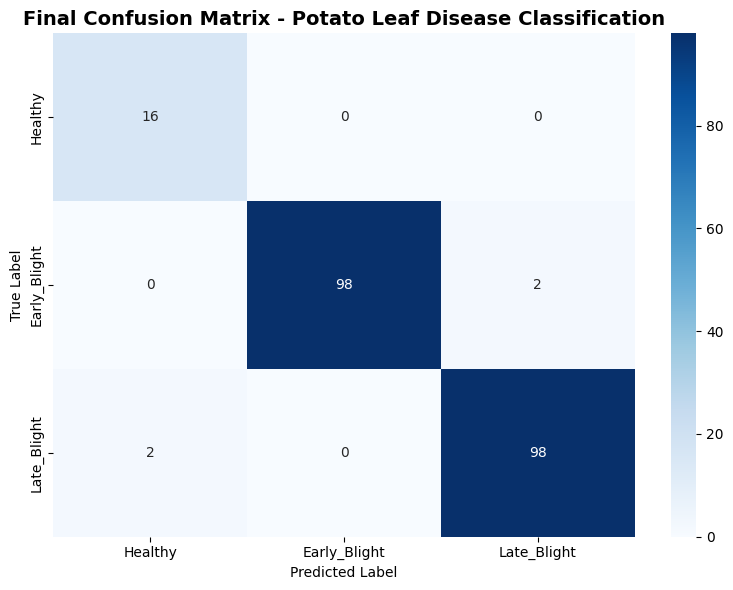


CLASS-WISE PERFORMANCE

Healthy
Total images     : 16
Correct          : 16
Incorrect        : 0
Class Accuracy   : 100.00%

Early_Blight
Total images     : 100
Correct          : 98
Incorrect        : 2
Class Accuracy   : 98.00%

Late_Blight
Total images     : 100
Correct          : 98
Incorrect        : 2
Class Accuracy   : 98.00%

FINAL EVALUATION SUMMARY
Model           : Potato_Leaf_CNN
Test Images     : 216
Test Loss       : 0.095172
Test Accuracy   : 98.15%
Classes         : ['Healthy', 'Early_Blight', 'Late_Blight']

✅ FINAL MODEL EVALUATION COMPLETED


In [3]:
# ============================================================================
# FINAL MODEL EVALUATION — SAVED CNN ON UNSEEN TEST DATA
# ============================================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================================
# 1. PATHS
# ============================================================================

PROJECT_DIR = '/content/drive/MyDrive/Plant Disease Detection (Computer Vision)'

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    '6th Trained_Model',
    'potato_cnn_best.keras'
)

PREPROC_FILE_PATH = os.path.join(
    PROJECT_DIR,
    '3rd Preprocessing',
    'processed_potato_data.npz'
)

class_names = [
    'Healthy',
    'Early_Blight',
    'Late_Blight'
]

# ============================================================================
# 2. VERIFY FILES
# ============================================================================

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print("\nModel exists :", os.path.exists(MODEL_PATH))
print("Test data exists :", os.path.exists(PREPROC_FILE_PATH))

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("Saved model not found.")

if not os.path.exists(PREPROC_FILE_PATH):
    raise FileNotFoundError("Processed test data not found.")


# ============================================================================
# 3. LOAD SAVED MODEL
# ============================================================================

print("\nLoading saved model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Saved model loaded successfully!")
print("Model name :", model.name)
print("Input shape :", model.input_shape)
print("Output shape :", model.output_shape)


# ============================================================================
# 4. LOAD UNSEEN TEST DATA
# ============================================================================

data = np.load(PREPROC_FILE_PATH)

X_test = data['X_test']
y_test = data['y_test']

print("\nTest dataset:")
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


# ============================================================================
# 5. MODEL EVALUATE — LOSS + ACCURACY
# ============================================================================

print("\n" + "=" * 70)
print("MODEL.EVALUATE()")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Test Accuracy : {:.2f}%".format(test_accuracy * 100))


# ============================================================================
# 6. GENERATE PREDICTIONS
# ============================================================================

print("\nGenerating predictions...")

y_pred_probs = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

print("✅ Predictions generated.")


# ============================================================================
# 7. CALCULATE ACCURACY AGAIN
# ============================================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy from predictions : {:.2f}%".format(
    accuracy * 100
))


# ============================================================================
# 8. CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)


# ============================================================================
# 9. CONFUSION MATRIX
# ============================================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


# ============================================================================
# 10. DISPLAY CONFUSION MATRIX
# ============================================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    'Final Confusion Matrix - Potato Leaf Disease Classification',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()


# ============================================================================
# 11. CLASS-WISE CORRECT / INCORRECT PREDICTIONS
# ============================================================================

print("\n" + "=" * 70)
print("CLASS-WISE PERFORMANCE")
print("=" * 70)

for i, class_name in enumerate(class_names):

    total = np.sum(y_test == i)
    correct = cm[i, i]
    incorrect = total - correct

    class_accuracy = correct / total * 100

    print(f"\n{class_name}")
    print("Total images     :", total)
    print("Correct          :", correct)
    print("Incorrect        :", incorrect)
    print("Class Accuracy   : {:.2f}%".format(class_accuracy))


# ============================================================================
# 12. FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("FINAL EVALUATION SUMMARY")
print("=" * 70)

print("Model           :", model.name)
print("Test Images     :", len(X_test))
print("Test Loss       :", round(float(test_loss), 6))
print("Test Accuracy   : {:.2f}%".format(test_accuracy * 100))
print("Classes         :", class_names)

print("\n✅ FINAL MODEL EVALUATION COMPLETED")

In [4]:
# ============================================================================
# REPEATABILITY CHECK
# ============================================================================

print("=" * 70)
print("REPEATABILITY CHECK")
print("=" * 70)

results = []

for run in range(5):

    probs = model.predict(
        X_test,
        verbose=0
    )

    predictions = np.argmax(
        probs,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        predictions
    )

    results.append(acc * 100)

    print(
        f"Run {run + 1}: {acc * 100:.2f}%"
    )

print("\nResults:", results)

if len(set(results)) == 1:
    print("\n✅ Model predictions are repeatable.")
else:
    print("\n⚠️ Prediction result changed between runs.")

REPEATABILITY CHECK
Run 1: 98.15%
Run 2: 98.15%
Run 3: 98.15%
Run 4: 98.15%
Run 5: 98.15%

Results: [98.14814814814815, 98.14814814814815, 98.14814814814815, 98.14814814814815, 98.14814814814815]

✅ Model predictions are repeatable.


In [5]:
# ============================================================================
# SAVED MODEL RELOAD + SINGLE IMAGE PREDICTION VERIFICATION
# ============================================================================

print("=" * 70)
print("SAVED MODEL RELOAD + PREDICTION VERIFICATION")
print("=" * 70)

# Reload model from disk
reloaded_model = tf.keras.models.load_model(MODEL_PATH)

print("\n✅ Model reloaded successfully.")

# Select one test image
sample_index = 0

sample_image = X_test[sample_index]
actual_class = y_test[sample_index]

# Add batch dimension
sample_batch = np.expand_dims(
    sample_image,
    axis=0
)

# Prediction
prediction_probs = reloaded_model.predict(
    sample_batch,
    verbose=0
)[0]

predicted_class = np.argmax(
    prediction_probs
)

confidence = prediction_probs[predicted_class] * 100

print("\n========== SAVED MODEL PREDICTION ==========")

print(
    "Actual Class    :",
    class_names[actual_class]
)

print(
    "Predicted Class :",
    class_names[predicted_class]
)

print(
    "Confidence      : {:.2f}%".format(confidence)
)

print(
    "Probabilities   :",
    prediction_probs
)

if actual_class == predicted_class:
    print("\n✅ Prediction is CORRECT")
else:
    print("\n❌ Prediction is INCORRECT")

SAVED MODEL RELOAD + PREDICTION VERIFICATION

✅ Model reloaded successfully.

========== SAVED MODEL PREDICTION ==========
Actual Class    : Late_Blight
Predicted Class : Late_Blight
Confidence      : 100.00%
Probabilities   : [5.4663267e-18 5.1290070e-12 1.0000000e+00]

✅ Prediction is CORRECT


In [6]:
# ==============================================================================
# FINAL VERIFICATION: FULL TEST DATA SAVED MODEL RELOAD CONSISTENCY
# ==============================================================================

import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

print("=" * 70)
print("FULL SAVED MODEL RELOAD + PREDICTION CONSISTENCY CHECK")
print("=" * 70)

# ---------------------------------------------------------
# 1. Verify model file
# ---------------------------------------------------------

print("\nChecking saved model file...")

print("Model exists :", os.path.exists(MODEL_PATH))

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Saved model not found:\n{MODEL_PATH}"
    )

# ---------------------------------------------------------
# 2. Prediction from currently loaded model
# ---------------------------------------------------------

print("\nGenerating predictions using CURRENT model...")

current_probs = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

current_predictions = np.argmax(
    current_probs,
    axis=1
)

current_accuracy = accuracy_score(
    y_test,
    current_predictions
)

print(f"Current model accuracy : {current_accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. Reload model from saved .keras file
# ---------------------------------------------------------

print("\nReloading model from saved file...")

reloaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("✅ Saved model reloaded successfully!")

print("Reloaded model name :", reloaded_model.name)
print("Reloaded input shape:", reloaded_model.input_shape)
print("Reloaded output shape:", reloaded_model.output_shape)

# ---------------------------------------------------------
# 4. Prediction using RELOADED model
# ---------------------------------------------------------

print("\nGenerating predictions using RELOADED model...")

reloaded_probs = reloaded_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

reloaded_predictions = np.argmax(
    reloaded_probs,
    axis=1
)

reloaded_accuracy = accuracy_score(
    y_test,
    reloaded_predictions
)

print(f"Reloaded model accuracy : {reloaded_accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 5. Compare predictions
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PREDICTION CONSISTENCY")
print("=" * 70)

same_predictions = np.array_equal(
    current_predictions,
    reloaded_predictions
)

different_predictions = np.sum(
    current_predictions != reloaded_predictions
)

print("Total test images       :", len(y_test))
print("Same predictions        :", np.sum(
    current_predictions == reloaded_predictions
))
print("Different predictions  :", different_predictions)

# ---------------------------------------------------------
# 6. Compare probabilities
# ---------------------------------------------------------

probabilities_same = np.allclose(
    current_probs,
    reloaded_probs,
    rtol=1e-5,
    atol=1e-6
)

print("Probabilities consistent:", probabilities_same)

# ---------------------------------------------------------
# 7. Final verification
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SAVED MODEL VERIFICATION")
print("=" * 70)

if same_predictions and probabilities_same:
    print("✅ FULL RELOAD CONSISTENCY VERIFIED")
    print("✅ Saved model produces identical predictions.")
    print("✅ Saved model produces consistent probabilities.")
    print("✅ Model can be safely reloaded for inference.")

else:
    print("⚠️ CONSISTENCY CHECK FAILED")
    print("⚠️ Current and reloaded model outputs differ.")

print("\nCurrent Model Accuracy  :", f"{current_accuracy * 100:.2f}%")
print("Reloaded Model Accuracy :", f"{reloaded_accuracy * 100:.2f}%")

print("\n" + "=" * 70)
print("MODEL EVALUATION + SAVED MODEL VERIFICATION COMPLETE")
print("=" * 70)

FULL SAVED MODEL RELOAD + PREDICTION CONSISTENCY CHECK

Checking saved model file...
Model exists : True

Generating predictions using CURRENT model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Current model accuracy : 98.15%

Reloading model from saved file...
✅ Saved model reloaded successfully!
Reloaded model name : Potato_Leaf_CNN
Reloaded input shape: (None, 224, 224, 3)
Reloaded output shape: (None, 3)

Generating predictions using RELOADED model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
Reloaded model accuracy : 98.15%

PREDICTION CONSISTENCY
Total test images       : 216
Same predictions        : 216
Different predictions  : 0
Probabilities consistent: True

FINAL SAVED MODEL VERIFICATION
✅ FULL RELOAD CONSISTENCY VERIFIED
✅ Saved model produces identical predictions.
✅ Saved model produces consistent probabilities.
✅ Model can be safely reloaded for inference.

Current Model Accuracy  : 98.15%
Reloaded Model Accuracy : 98.15%

MODEL EVALUATION + SAVED MODEL VERIFICATION COMPLETE
